# Metacells

# Use PCs identified using first part of R pipeline, so that it's also possible to incorporate batch correction if needed.

In [1]:
######################
## Import libraries ##
######################

import os
from re import search
import SEACells

findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Lato'] not found. Falling back to DejaVu Sans.


In [2]:
###########################
## Load default settings ##
###########################
exec(open('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code/settings.py').read())
exec(open('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code/utils.py').read())

In [3]:

## START TEST ##
args = {}
args["anndata"] = io["basedir"] + "/data/processed/rna/anndata.h5ad"
args["metadata"] = io["basedir"] + "/results/rna/mapping/sample_metadata_after_mapping.txt.gz"
args["samples"] = ['E7.5_rep1','E7.5_rep2','E7.75_rep1','E8.0_rep1','E8.0_rep2','E8.5_rep1','E8.5_rep2','E8.75_rep1','E8.75_rep2']
args["trajectory"] = "blood"
args["percent_metacells"] = 0.05
args["n_features"] = 1500
args["n_pcs"] = 25
args["outdir"] = io["basedir"] + "/results/rna_atac/gene_regulatory_networks/metacells/trajectories/erythroid"
## END TEST ##

In [4]:
PCA = pd.read_csv(args["outdir"] + '/PCA_25.csv').set_index('cell')


In [6]:
#####################
## Parse arguments ##
#####################

# I/O
if not os.path.isdir(args["outdir"]): os.makedirs(args["outdir"])
#args["outdir"] = Path(args["outdir"])

sc.settings.figdir = args["outdir"] + "/pdf"

# Options
if args["trajectory"]=="nmp":
  # args["samples"] = ["E8.5_CRISPR_T_KO", "E8.5_CRISPR_T_WT"]
  opts["samples"] = ["E8.0_rep1", "E8.0_rep2", "E8.5_rep1", "E8.5_rep2", "E8.75_rep1", "E8.75_rep2", "E8.5_CRISPR_T_KO", "E8.5_CRISPR_T_WT"]
  opts["celltypes"] = ["Caudal_Mesoderm", "Somitic_mesoderm", "NMP", "Spinal_cord"]
elif args["trajectory"]=="epiblast_blood":
  # args["samples"] = ["E8.5_CRISPR_T_KO", "E8.5_CRISPR_T_WT"]
  opts["samples"] = ['E7.5_rep1','E7.5_rep2','E7.75_rep1','E8.0_rep1','E8.0_rep2','E8.5_rep1','E8.5_rep2','E8.75_rep1','E8.75_rep2']
  opts["celltypes"] = ["Epiblast",
                        "Primitive_Streak" ,
                        "Nascent_mesoderm",
                        "ExE_mesoderm",
                        "Mixed_mesoderm",
                        "Allantois",
                        "Mesenchyme",
                        "Haematoendothelial_progenitors",
                        "Endothelium",
                        "Blood_progenitors_1",
                        "Blood_progenitors_2",
                        "Erythroid1",
                        "Erythroid2",
                        "Erythroid3"]
elif args["trajectory"]=="blood":
  # args["samples"] = ["E8.5_CRISPR_T_KO", "E8.5_CRISPR_T_WT"]
  opts["samples"] = ['E7.5_rep1','E7.5_rep2','E7.75_rep1','E8.0_rep1','E8.0_rep2','E8.5_rep1','E8.5_rep2','E8.75_rep1','E8.75_rep2']
  opts["celltypes"] = ["Haematoendothelial_progenitors", "Blood_progenitors_1", "Blood_progenitors_2", "Erythroid1", "Erythroid2", "Erythroid3"]
else:
  print("Trajectory not known")
  exit()

print("Infering metacells for %s trajectory..." % args["trajectory"])

if isinstance(args["samples"],list): 
  if args["samples"][0]=="all":
    args["samples"] = opts["samples"]
  else:
    assert set(args["samples"]).issubset(opts["samples"])

else:
  print('args["samples"] has to be a list')

print(args)

Infering metacells for blood trajectory...
{'anndata': '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/rna/anndata.h5ad', 'metadata': '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna/mapping/sample_metadata_after_mapping.txt.gz', 'samples': ['E7.5_rep1', 'E7.5_rep2', 'E7.75_rep1', 'E8.0_rep1', 'E8.0_rep2', 'E8.5_rep1', 'E8.5_rep2', 'E8.75_rep1', 'E8.75_rep2'], 'trajectory': 'blood', 'percent_metacells': 0.05, 'n_features': 1500, 'n_pcs': 25, 'outdir': '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna_atac/gene_regulatory_networks/metacells/trajectories/erythroid'}


In [7]:
###################
## Load metadata ##
###################

metadata = (pd.read_table(args["metadata"]) >>
    # mask(X["pass_rnaQC"]==True, X["pass_atacQC"]==True, X["doublet_call"]==False, X["celltype"].isin(opts["celltypes"])) >>
    mask(X["pass_rnaQC"]==True, X["doublet_call"]==False, X["celltype"].isin(opts["celltypes"])) >>
    mask(X["sample"].isin(args["samples"]))
).set_index("cell", drop=False)

print(metadata.shape)
print(metadata.head())

(4438, 15)
                                                      cell  \
cell                                                         
E7.5_rep1#AAACATGCAGGATAAC-1  E7.5_rep1#AAACATGCAGGATAAC-1   
E7.5_rep1#AAACCGGCAACCTAAT-1  E7.5_rep1#AAACCGGCAACCTAAT-1   
E7.5_rep1#AAACGTACATGCTCCC-1  E7.5_rep1#AAACGTACATGCTCCC-1   
E7.5_rep1#AAAGCACCATTTGCTC-1  E7.5_rep1#AAAGCACCATTTGCTC-1   
E7.5_rep1#AAAGCCGCACAGCCAT-1  E7.5_rep1#AAAGCCGCACAGCCAT-1   

                                         barcode     sample  nFeature_RNA  \
cell                                                                        
E7.5_rep1#AAACATGCAGGATAAC-1  AAACATGCAGGATAAC-1  E7.5_rep1          4158   
E7.5_rep1#AAACCGGCAACCTAAT-1  AAACCGGCAACCTAAT-1  E7.5_rep1          3407   
E7.5_rep1#AAACGTACATGCTCCC-1  AAACGTACATGCTCCC-1  E7.5_rep1          4095   
E7.5_rep1#AAAGCACCATTTGCTC-1  AAAGCACCATTTGCTC-1  E7.5_rep1          2769   
E7.5_rep1#AAAGCCGCACAGCCAT-1  AAAGCCGCACAGCCAT-1  E7.5_rep1          2840   

              

/tmp/ipykernel_150739/1927894653.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = (pd.read_table(args["metadata"]) >>


In [8]:
##################
## Load AnnData ##
##################

adata = load_adata(
	adata_file = args["anndata"], 
	metadata_file = args["metadata"], 
	cells = metadata.index.values, 
	normalise = True, 
  keep_counts = True,
	filter_lowly_expressed_genes = True, 
	set_colors = False
)

# Set colors
colPalette_celltypes = [opts["celltype_colors"][i.replace(" ","_")] for i in sorted(np.unique(adata.obs['celltype']))]
adata.uns['celltype_colors'] = colPalette_celltypes

0.00% of cells provided are not observed in the adata, taking the intersect...


<string>:28: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.


In [9]:
adata

AnnData object with n_obs × n_vars = 4438 × 18308
    obs: 'cell', 'barcode', 'sample', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'stage', 'genotype', 'pass_rnaQC', 'doublet_score', 'doublet_call', 'celltype', 'celltype.score', 'closest.cell'
    var: 'gene', 'n_counts'
    uns: 'log1p', 'celltype_colors'
    layers: 'raw'

In [10]:
#######################
## Feature selection ##
#######################

sc.pp.highly_variable_genes(adata, n_top_genes=args["n_features"])

In [11]:
##############################
## Dimensionality reduction ##
##############################

# Load dim redu
PCA_array = PCA.to_numpy()
adata.obsm['X_pca'] = PCA_array

#sc.tl.pca(adata, n_comps=args["n_pcs"], svd_solver='arpack', use_highly_variable=True)

# Build kNN graph
sc.pp.neighbors(adata, n_neighbors=25, use_rep='X_pca')

# Run UMAP
# sc.tl.umap(adata, min_dist=0.5, n_components=2)

# Plot UMAP
# sc.pl.umap(adata, color=["celltype"], size=25, legend_loc=None, save=args["outdir"] / "pdf/umap.pdf")

findfont: Font family ['Bitstream Vera Sans'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Bitstream Vera Sans'] not found. Falling back to DejaVu Sans.


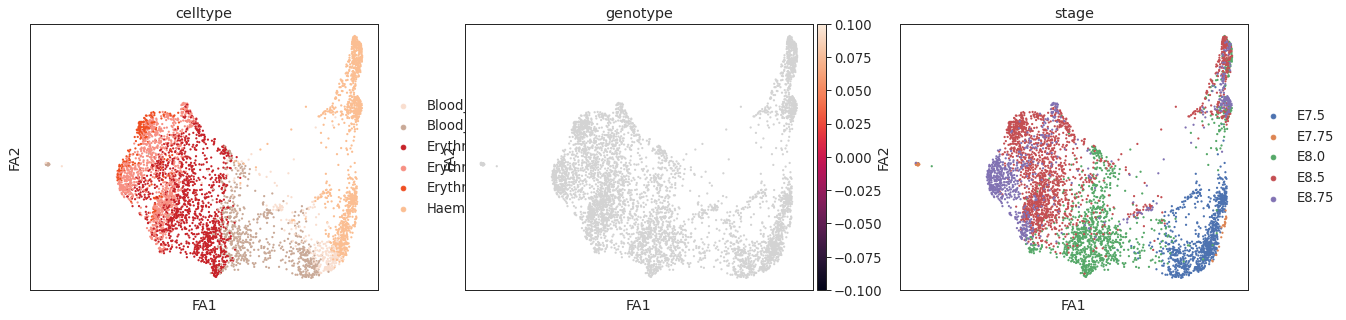

In [12]:
# Run Force Atlas
sc.tl.draw_graph(adata, layout='fa', init_pos=None)
sc.pl.draw_graph(adata, color=["celltype","genotype","stage"], size=20, save="_trajectory.pdf")

In [13]:
########################
## Fit metacell model ##
########################

n_metacells = round(args["percent_metacells"] * adata.shape[0])

print("Fitting SEACells with %d metacells..." % (n_metacells))

model = SEACells.core.SEACells(adata, 
                  build_kernel_on = 'X_pca',  # this should be on PCs instead of FA2
                  n_SEACells = n_metacells, 
                  n_waypoint_eigs=10,
                  waypt_proportion=1,
                  convergence_epsilon = 1e-6)

model.fit()

adata.obs[['SEACell']].head()

Fitting SEACells with 222 metacells...
Building kernel...
Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/4438 [00:00<?, ?it/s]

Making graph symmetric...
Computing RBF kernel...


  0%|          | 0/4438 [00:00<?, ?it/s]

Building similarity LIL matrix...


...

/home/bt392/miniconda3/envs/metacells/lib/python3.9/site-packages/palantir/utils.py:54: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  temp = sc.AnnData(data_df.values)


Done.
Sampling waypoints ...
Done.
Selecting 203 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


  0%|          | 0/29 [00:00<?, ?it/s]

Selecting 19 cells from greedy initialization.
Randomly initialized A matrix.
Setting convergence threshold at 0.0006767985594678995
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Converged after 10 iterations.


,SEACell
index,
E7.5_rep1#AAACATGCAGGATAAC-1,E7.5_rep1#TAGTTGTCAGTTTGTG-1
E7.5_rep1#AAACCGGCAACCTAAT-1,E7.5_rep1#TACTAAGTCTCAATTC-1
E7.5_rep1#AAACGTACATGCTCCC-1,E7.5_rep1#TTAGCGGTCACTTCAT-1
E7.5_rep1#AAAGCACCATTTGCTC-1,E7.5_rep1#AGCTTAATCCTGCGAA-1
E7.5_rep1#AAAGCCGCACAGCCAT-1,E7.5_rep2#ACCCGGTAGGCCTGGT-1


In [14]:
args["outdir"] + "/pdf/model_convergence.pdf"

'/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna_atac/gene_regulatory_networks/metacells/trajectories/erythroid/pdf/model_convergence.pdf'

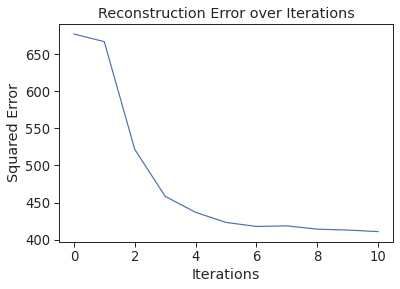

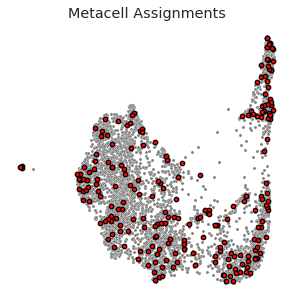

In [15]:
#######################
## Plot model output ##
#######################

model.plot_convergence(save_as=args["outdir"] + "/pdf/model_convergence.pdf")

SEACells.plot.plot_2D(adata, key='X_draw_graph_fa', colour_metacells=False, save_as=args["outdir"] + "/pdf/forceatlas_highlight_metacells.pdf")


In [16]:
## Calculate celltype purity!
SEACell_purity = SEACells.evaluate.compute_celltype_purity(adata, 'celltype')
SEACell_purity = SEACell_purity.reset_index()
SEACell_purity.columns = ["metacell", 'celltype', 'celltype_purity']

  0%|          | 0/222 [00:00<?, ?it/s]

/rds/project/rds-SDzz0CATGms/users/bt392/software/github/SEACells/SEACells/core.py:560: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  meta_ad = sc.AnnData(csr_matrix(summ_matrix))


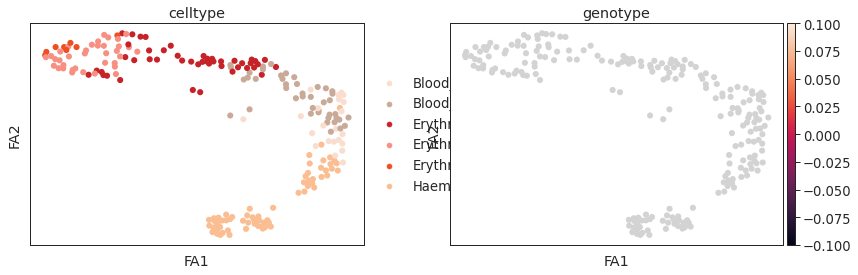

In [17]:
################################################################
## Aggregate counts and plot trajectory at the metacell level ##
################################################################

adata_metacells = SEACells.core.summarize_by_SEACell(adata, SEACells_label='SEACell', summarize_layer='raw')
adata_metacells.uns = adata.uns
adata_metacells.obs = (adata.obs.loc[adata_metacells.obs.index] >> 
    select(["sample","celltype","genotype"])
)
sc.pp.normalize_total(adata_metacells)
sc.pp.log1p(adata_metacells)
sc.pp.highly_variable_genes(adata_metacells, n_top_genes=1500)
sc.tl.pca(adata_metacells, n_comps=10)
sc.pp.neighbors(adata_metacells, n_neighbors=15, use_rep='X_pca')
sc.tl.draw_graph(adata_metacells, layout="fa", init_pos=None)
sc.pl.draw_graph(adata_metacells, color=["celltype","genotype"], size=150, save="_metacell_trajectory.pdf")


In [18]:
##########
## Save ##
##########

# Save trajectory coordinates
to_save = pd.DataFrame(adata_metacells.obsm["X_draw_graph_fa"], index=adata_metacells.obs_names, columns=["FA1","FA2"])
to_save.to_csv(args["outdir"] + "/metacell_trajectory.txt.gz", sep='\t')

# Save cell2metacell assignemnt
to_save = adata.obs[['SEACell']].reset_index()
to_save.columns = ["cell","metacell"]
to_save = to_save.merge(SEACell_purity, on='metacell')
to_save.to_csv(args["outdir"] + "/cell2metacell_assignment.txt.gz", sep="\t", header=True, index=False)

# Save anndata
#adata_metacells.write_h5ad(args["outdir"] + "/anndata_metacells.h5ad")